# Opdracht 1

### Kaggle Team
**El Clasico**
- Ciaran Smit (ciarans15)
- Eduard Bunatyan (eduardbunatyan)
- Zdravko Nezirov (zdravkonezirov)
- Imran Funna (imranfunna)

In [ ]:
pip install -r requirements.txt


In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from IPython.display import display
from pathlib import Path
from sklearn.neighbors import NearestNeighbors #DBSCAN
from sklearn.cluster import DBSCAN #DBSCAN

import warnings
warnings.filterwarnings('ignore')

#DataFrame maken
df = pd.read_csv('labels_new.csv')

In [2]:
#Information df
display(df.head())
print("aantal samples:",len(df))
print("aantal genres:",df['genre'].nunique())
display(df['genre'].value_counts())

,filename,genre
0,m00248.wav,metal
1,m00230.wav,country
2,m00637.wav,hiphop
3,m00627.wav,metal
4,m00138.wav,reggae


aantal samples: 50
aantal genres: 10


genre
metal        5
country      5
hiphop       5
reggae       5
classical    5
jazz         5
rock         5
pop          5
blues        5
disco        5
Name: count, dtype: int64

In [3]:
#Labeled and unlabeled directions and files
labeled_audio_dir = Path('labeled')
labeled_audio_files = os.listdir(labeled_audio_dir)

unlabeled_audio_dir = Path('unlabeled')
unlabeled_audio_files = os.listdir(unlabeled_audio_dir)
df_unlabeled = pd.DataFrame(os.listdir(unlabeled_audio_dir))

In [4]:
#https://librosa.org/doc/latest/feature.html

class LibrosaFeatures:

    def __init__(self, audio_dir):
        self.audio_dir = Path(audio_dir)
        self.features_list = []

    def features(self, audio_files):
        self.features_list = [] 
        for file in audio_files:
            file_path = self.audio_dir / file
            features = self.process_file(file_path, file)
            self.features_list.append(features)
        return pd.DataFrame(self.features_list)

    def process_file(self, file_path, file):
        y, sr = librosa.load(file_path)

        features = {
            'filename': file,
            'spectral_bandwidth': np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
            'spectral_bandwidth_std': np.std(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
            'spectral_centroid': np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
            'spectral_centroid_std': np.std(librosa.feature.spectral_centroid(y=y, sr=sr)),
            'zero_crossing_rate': np.mean(librosa.feature.zero_crossing_rate(y)),
            'zero_crossing_rate_std': np.std(librosa.feature.zero_crossing_rate(y)),
            'rms': np.mean(librosa.feature.rms(y=y)),
            'rms_std': np.std(librosa.feature.rms(y=y)),
            'rolloff': np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)),
            'flatness': np.mean(librosa.feature.spectral_flatness(y=y)),
            'tempo': librosa.beat.tempo(y=y, sr=sr)[0]}

        #Rhythm
        rhythm = librosa.onset.onset_strength(y=y, sr=sr)
        tempo, beats = librosa.beat.beat_track(onset_envelope=rhythm, sr=sr)

        features.update({
            'onset_strength_mean': np.mean(rhythm),
            'onset_strength_std': np.std(rhythm),
            'beat_strength': np.mean(librosa.util.normalize(rhythm)[beats]) if len(beats) > 0 else 0
        })

        #Harmonic
        harmonic, percussive = librosa.effects.hpss(y)
        features.update({
            'harmonic_ratio': np.mean(np.abs(harmonic)) / (np.mean(np.abs(percussive)) + 1e-8),
            'percussive_ratio': np.mean(np.abs(percussive)) / (np.mean(np.abs(harmonic)) + 1e-8)
        })

        #MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            features[f'mfcc_{i+1}'] = np.mean(mfcc[i])
            features[f'mfcc_{i+1}_std'] = np.std(mfcc[i])

        #Chromagram
        chromagram = librosa.feature.chroma_stft(y=y, sr=sr)
        for i in range(12):
            features[f'chroma_{i+1}'] = np.mean(chromagram[i])
            features[f'chroma_{i+1}_std'] = np.std(chromagram[i])

        #Tempogram
        tempogram = librosa.feature.tempogram(y=y, sr=sr)
        features.update({
            'tempogram_ratio': np.mean(tempogram) / (np.std(tempogram) + 1e-8),
            'tempogram_std': np.std(tempogram)
        })

        return features

    def merge(self, labels_df):
        features_df = pd.DataFrame(self.features_list)
        return pd.merge(features_df, labels_df, on='filename')

#Remove warnings
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    pull = LibrosaFeatures(labeled_audio_dir)
    df_features = pull.features(labeled_audio_files)
    df_audio_features = pull.merge(df)

#Columns check
df_audio_features.columns

Index(['filename', 'spectral_bandwidth', 'spectral_bandwidth_std',
       'spectral_centroid', 'spectral_centroid_std', 'zero_crossing_rate',
       'zero_crossing_rate_std', 'rms', 'rms_std', 'rolloff', 'flatness',
       'tempo', 'onset_strength_mean', 'onset_strength_std', 'beat_strength',
       'harmonic_ratio', 'percussive_ratio', 'mfcc_1', 'mfcc_1_std', 'mfcc_2',
       'mfcc_2_std', 'mfcc_3', 'mfcc_3_std', 'mfcc_4', 'mfcc_4_std', 'mfcc_5',
       'mfcc_5_std', 'mfcc_6', 'mfcc_6_std', 'mfcc_7', 'mfcc_7_std', 'mfcc_8',
       'mfcc_8_std', 'mfcc_9', 'mfcc_9_std', 'mfcc_10', 'mfcc_10_std',
       'mfcc_11', 'mfcc_11_std', 'mfcc_12', 'mfcc_12_std', 'mfcc_13',
       'mfcc_13_std', 'chroma_1', 'chroma_1_std', 'chroma_2', 'chroma_2_std',
       'chroma_3', 'chroma_3_std', 'chroma_4', 'chroma_4_std', 'chroma_5',
       'chroma_5_std', 'chroma_6', 'chroma_6_std', 'chroma_7', 'chroma_7_std',
       'chroma_8', 'chroma_8_std', 'chroma_9', 'chroma_9_std', 'chroma_10',
       'chroma_10_st

# Alle features + manier van bepalen/berekenen:

### filename

Betekenis: naam van het audiobestand.
Berekening: niet berekend, dit is metadata van het bestand.

### genre

Betekenis: muziekgenre van het nummer.
Berekening: meestal handmatig gelabeld of afkomstig uit de dataset.

### spectral_centroid

Betekenis: geeft aan of het geluid vooral hoge of lage tonen bevat.
Berekening: het gewogen gemiddelde van alle frequenties in het spectrum.

### spectral_bandwidth

Betekenis: hoe breed het frequentiespectrum is.
Berekening: de spreiding van frequenties rondom de spectral centroid.

### rolloff

Betekenis: grensfrequentie waar het grootste deel van de energie onder zit.
Berekening: de frequentie waaronder een groot deel (bijvoorbeeld 85%) van de totale energie valt.

### flatness

Betekenis: geeft aan of een geluid meer lijkt op ruis of op een toon.
Berekening: verhouding tussen het geometrisch en rekenkundig gemiddelde van het spectrum.

### spectral_centroid_std / spectral_bandwidth_std

Betekenis: hoe sterk de spectral centroid / bandwidth varieert in de tijd.
Berekening: standaarddeviatie van de waarden over alle frames.

### rms

Betekenis: gemiddelde luidheid van het geluid.
Berekening: wortel van het gemiddelde van de kwadraten van het signaal.

### rms_std

Betekenis: variatie in luidheid.
Berekening: standaarddeviatie van RMS over de tijd.

### zero_crossing_rate

Betekenis: hoe vaak het signaal van positief naar negatief gaat.
Berekening: aantal nuldoorgangen per frame gedeeld door het aantal samples.

### zero_crossing_rate_std

Betekenis: variatie in zero crossing rate.
Berekening: standaarddeviatie van ZCR over frames.

### tempo

Betekenis: snelheid van de muziek (BPM).
Berekening: gevonden uit herhalende patronen in het audiosignaal.

### onset_strength_mean

Betekenis: hoe sterk nieuwe geluiden of noten gemiddeld beginnen.
Berekening: verschil in energie tussen opeenvolgende frames, gemiddeld over de tijd.

### onset_strength_std

Betekenis: variatie in sterkte van nieuwe geluidsaanzetten.
Berekening: standaarddeviatie van onset strength.

### beat_strength

Betekenis: hoe duidelijk en sterk de beat aanwezig is.
Berekening: afgeleid uit regelmaat en intensiteit van beats.

### tempogram_ratio

Betekenis: verhouding tussen dominante ritmepatronen.
Berekening: analyse van tempo-patronen in de tijd.

### tempogram_std

Betekenis: variatie in ritmepatronen.
Berekening: standaarddeviatie van tempogramwaarden.

### harmonic_ratio

Betekenis: hoeveel van het geluid bestaat uit tonen.
Berekening: energie van harmonische componenten gedeeld door totale energie.

### percussive_ratio

Betekenis: hoeveel van het geluid bestaat uit percussie.
Berekening: energie van percussieve componenten gedeeld door totale energie.

### mfcc_1 t/m mfcc_13

Betekenis: beschrijven de klankkleur van het geluid.
Berekening:

1. spectrum berekenen met fouriertransformatie

2. Mel-filterbank toepassen

3. log-energie nemen

4. cosine-transformatie uitvoeren

elke MFCC meet een ander aspect van de klank.

### mfcc_X_std

Betekenis: variatie van MFCC-waarden in de tijd.
Berekening: standaarddeviatie van de MFCC over frames.

### chroma_1 t/m chroma_12

Betekenis: hoeveel energie er zit in elke toonklasse.
Berekening: frequenties worden gekoppeld aan toonklassen en energie wordt per klasse opgeteld.

### chroma_X_std

Betekenis: variatie van toonklassen over de tijd.
Berekening: standaarddeviatie van chroma-waarden.

# Opdracht 2

Welke DataFrames hebben we nu allemaal? Hiermee gaan we werken om de clusters te maken en het beste model te vinden om de hoogste accuracy op kaggle te voorspellen.

In [5]:
#Labeled
display(df.head())
#Unlabeled
display(df_unlabeled.head())
#Audio features
display(df_audio_features.head())

,filename,genre
0,m00248.wav,metal
1,m00230.wav,country
2,m00637.wav,hiphop
3,m00627.wav,metal
4,m00138.wav,reggae


,0
0,m00003.wav
1,m00012.wav
2,m00013.wav
3,m00043.wav
4,m00044.wav


,filename,spectral_bandwidth,spectral_bandwidth_std,spectral_centroid,spectral_centroid_std,zero_crossing_rate,zero_crossing_rate_std,rms,rms_std,rolloff,...,chroma_9_std,chroma_10,chroma_10_std,chroma_11,chroma_11_std,chroma_12,chroma_12_std,tempogram_ratio,tempogram_std,genre
0,m00002.wav,1920.270843,352.469828,1451.862124,428.935223,0.051224,0.025074,0.050480,0.027131,3047.431199,...,0.377096,0.287583,0.328681,0.224478,0.326612,0.185700,0.306980,0.869013,0.200426,jazz
1,m00039.wav,2019.300256,442.196748,1811.410394,809.772584,0.072150,0.051697,0.123665,0.053056,3854.851374,...,0.223918,0.297682,0.275615,0.422818,0.337206,0.401892,0.297101,0.747660,0.139721,reggae
2,m00041.wav,2992.010638,346.836989,3110.898196,779.418889,0.152857,0.068744,0.198322,0.077807,6744.988603,...,0.323897,0.332073,0.237859,0.445475,0.354692,0.293710,0.220588,0.802305,0.187328,pop
3,m00072.wav,2709.897108,360.419232,2624.814629,585.287392,0.120217,0.038883,0.142927,0.062914,5605.777240,...,0.329127,0.282717,0.175517,0.376277,0.294601,0.277690,0.236222,0.806668,0.193607,disco
4,m00096.wav,2485.524548,368.525304,2549.269757,695.078336,0.115834,0.050427,0.184340,0.098477,5583.144894,...,0.298731,0.244928,0.281050,0.239062,0.275884,0.318006,0.307679,0.729187,0.165431,disco


---

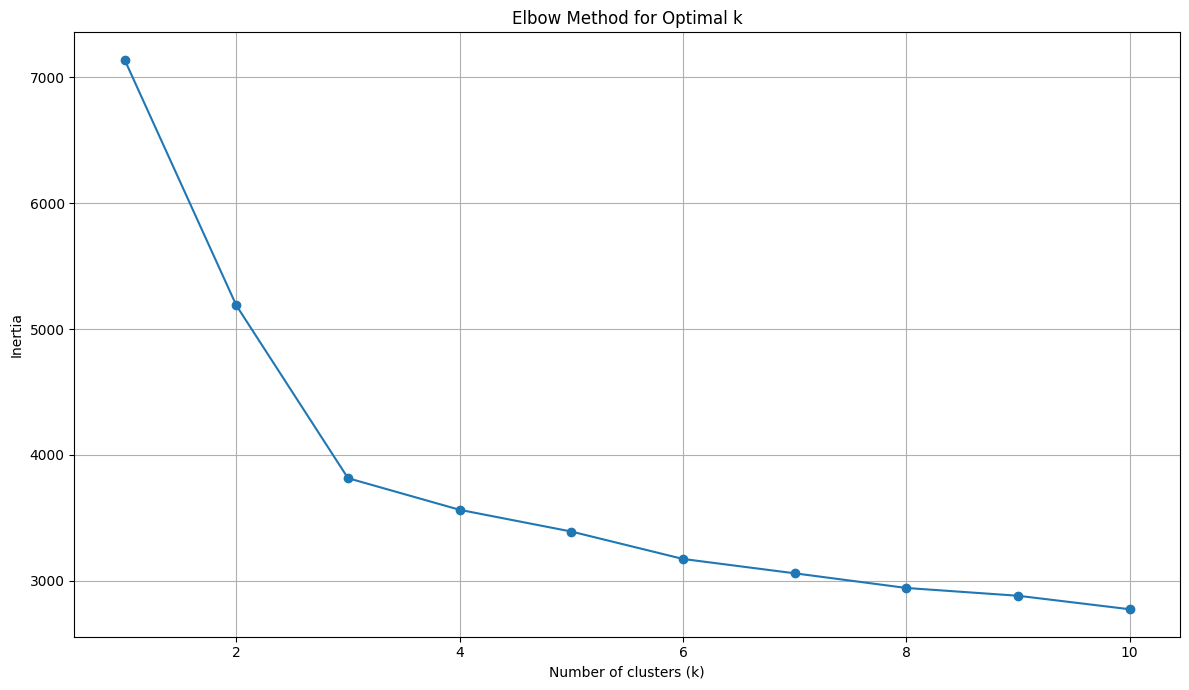

In [6]:
#Remove warnings, hierdoor meer clean output.
os.environ["OMP_NUM_THREADS"] = "1"

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)

warnings.filterwarnings(
    "ignore",
    message="librosa.beat.tempo"
)

unlabeled_features = LibrosaFeatures(unlabeled_audio_dir).features(unlabeled_audio_files)
X = unlabeled_features.drop("filename", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Elbow Method
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

#Plotting
plt.figure(figsize=(12, 7))
plt.plot(K, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.tight_layout()
plt.show()

Om het optimale aantal clusters te bepalen, zijn de audiofeatures van de unlabeled dataset eerst genormaliseerd. Dit is nodig omdat de features verschillende schalen hebben. Door standaardisatie krijgen alle features een vergelijkbare invloed op de clustering.

Vervolgens is de Elbow-methode toegepast. Hierbij wordt het clusteringalgoritme KMeans meerdere keren uitgevoerd met verschillende aantallen clusters. Voor elke waarde van k wordt de inertia berekend, wat de totale afstand is van alle punten tot het centrum van hun cluster.

De inertia daalt sterk bij kleine waarden van k, maar vanaf een bepaald punt neemt de verbetering af. Dit punt wordt de “elleboog” genoemd en wordt geïnterpreteerd als het optimale aantal clusters. In dit geval ligt de elleboog rond k = 3, wat betekent dat drie clusters een goede balans bieden tussen modelcomplexiteit en kwaliteit van de clustering.

Daarnaast is hieronder gekeken naar de prestaties van verschillende aantallen clusters op Kaggle. Hierbij bleek dat drie clusters ook de beste resultaten opleverden. Daarom is gekozen voor drie clusters.

---

# KMeans

3 clusters - 0.98 Kaggle score

In [7]:
#KMeans
kmeans = KMeans(n_clusters = 3, random_state=42)
unlabeled_features["clusters"] = kmeans.fit_predict(X_scaled)
df_unlabeled["clusters"] = kmeans.labels_
genres = {
    0: "pop",
    1: "metal",
    2: "classical"
}
df_unlabeled["genre"] = df_unlabeled["clusters"].map(genres)

#Submission
#df_unlabeled.rename(columns={0: 'filename'}, inplace=True)
#df_unlabeled[['filename', 'genre']].to_csv(
#    'submission_01.csv',
#    index=False
#)

4 clusters - 0.66 Kaggle score

In [8]:
#KMeans
kmeans = KMeans(n_clusters = 4, random_state=42)
unlabeled_features["clusters"] = kmeans.fit_predict(X_scaled)
df_unlabeled["clusters"] = kmeans.labels_
genres = {
    0: "pop",
    1: "metal",
    2: "classical"
}
df_unlabeled["genre"] = df_unlabeled["clusters"].map(genres)

#Submission
#df_unlabeled.rename(columns={0: 'filename'}, inplace=True)
#df_unlabeled[['filename', 'genre']].to_csv(
#    'submission_02.csv',
#    index=False
#)

10 clusters - 0.13 Kaggle score

In [9]:
#KMeans
kmeans = KMeans(n_clusters = 10, random_state=42)
unlabeled_features["clusters"] = kmeans.fit_predict(X_scaled)
df_unlabeled["clusters"] = kmeans.labels_
genres = {
    0: "pop",
    1: "metal",
    2: "classical"
}
df_unlabeled["genre"] = df_unlabeled["clusters"].map(genres)

#Submission
#df_unlabeled.rename(columns={0: 'filename'}, inplace=True)
#df_unlabeled[['filename', 'genre']].to_csv(
#    'submission_03.csv',
#    index=False
#)

---

Vikram had een advies gegeven om naar de fout te kijken ipv naar de verbetering als het model al zo goed voorspeld. Dus we gaan nu kijken welke genres extreem dichtbij elkaar liggen om te kijken als we daar wat aanpassingen doen of we naar de 100% kunnen.

In [10]:
feature_cols = [c for c in df_audio_features.columns if c not in ["filename", "genre"]]

X_unlabeled = unlabeled_features[feature_cols].values

scaler = StandardScaler()
X_unlabeled_scaled = scaler.fit_transform(X_unlabeled)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
unlabeled_labels = kmeans.fit_predict(X_unlabeled_scaled)

unlabeled_features["clusters"] = unlabeled_labels

genres = {0: "pop", 1: "metal", 2: "classical"}
unlabeled_features["genre"] = unlabeled_features["clusters"].map(genres)

distances = pairwise_distances(X_unlabeled_scaled, kmeans.cluster_centers_)

distance_df = pd.DataFrame(
    distances,
    columns=[f"dist_to_cluster_{i}" for i in range(kmeans.n_clusters)]
)

distance_df["filename"] = unlabeled_features["filename"].tolist()
distance_df["assigned_cluster"] = unlabeled_labels

for cluster_idx, genre_name in genres.items():
    distance_df[f"dist_to_{genre_name}"] = distance_df[f"dist_to_cluster_{cluster_idx}"]

def margin(row):
    dists = sorted([row["dist_to_classical"], row["dist_to_metal"], row["dist_to_pop"]])
    return dists[1] - dists[0]

distance_df["margin"] = distance_df.apply(margin, axis=1)

def second_best_gap(row):
    dists = sorted([row["dist_to_classical"], row["dist_to_metal"], row["dist_to_pop"]])
    return dists[1] - dists[0]

distance_df["gap"] = distance_df.apply(second_best_gap, axis=1)

ambiguous = distance_df[
    (distance_df["gap"] < 3.5) &
    (distance_df[["dist_to_classical", "dist_to_metal", "dist_to_pop"]].min(axis=1) > 5)
]

from IPython.display import display
display(
    ambiguous[["filename", "dist_to_classical", "dist_to_metal", "dist_to_pop", "margin"]]
    .sort_values("margin")
)


,filename,dist_to_classical,dist_to_metal,dist_to_pop,margin
73,m00719.wav,9.705620,7.627062,6.867040,0.760022
10,m00107.wav,10.340593,7.767337,6.463853,1.303485
85,m00829.wav,9.791594,10.928081,8.046709,1.744885
91,m00921.wav,8.983934,10.803238,12.569360,1.819304
12,m00127.wav,9.531063,11.414122,12.019335,1.883058
31,m00323.wav,11.212389,14.468649,13.177590,1.965201
63,m00582.wav,6.758296,10.153085,8.819537,2.061241
13,m00137.wav,10.941839,8.803087,6.691060,2.112027
23,m00254.wav,9.293938,7.170996,10.193500,2.122943
53,m00528.wav,9.914654,8.616348,6.451005,2.165343


In [11]:
def classical_pop_first_two(row):
    dists = {"classical": row["dist_to_classical"],
             "metal": row["dist_to_metal"],
             "pop": row["dist_to_pop"]}
    sorted_dists = sorted(dists.items(), key=lambda x: x[1])
    return sorted_dists[0][0] == "classical" and sorted_dists[1][0] == "pop"

selected_final = ambiguous[ambiguous.apply(classical_pop_first_two, axis=1)]
selected_final = selected_final[selected_final["dist_to_classical"] < 8]

display(selected_final[["filename", "dist_to_classical", "dist_to_pop", 
                        "margin"]].sort_values("margin"))

,filename,dist_to_classical,dist_to_pop,margin
63,m00582.wav,6.758296,8.819537,2.061241
69,m00635.wav,7.471597,10.689465,3.217868
93,m00928.wav,7.680668,11.079719,3.399051


Ik ga eerst checken of er een verbetering komt als ik 63 en 93 van classical naar pop verander. We hebben nu een 100% accuracy dus kijken we niet meer naar andere waarden.

KMeans verdeelt de dataset in een vooraf gekozen aantal clusters. Het algoritme werkt iteratief: eerst worden clustercentra willekeurig gekozen, daarna worden datapunten toegewezen aan het dichtstbijzijnde centrum. Vervolgens worden de clustercentra opnieuw berekend op basis van de toegewezen punten. Dit proces herhaalt zich totdat de clusterindeling stabiel is.

Het doel van KMeans is om de totale afstand tussen datapunten en hun clustercentrum te minimaliseren. Het algoritme werkt goed wanneer clusters ongeveer vergelijkbare grootte hebben.

---

# Hierarchical

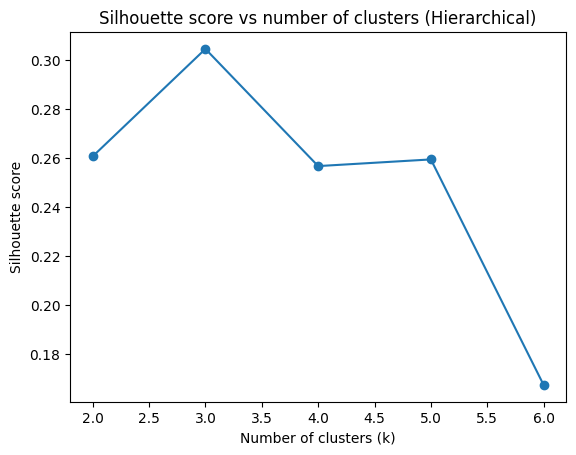

In [12]:
from sklearn.metrics import silhouette_score

k_values = range(2, 7)
scores = []

for k in k_values:
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs number of clusters (Hierarchical)")
plt.show()

In [13]:
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_unlabeled["clusters"] = hierarchical.fit_predict(X_scaled)

genres = {
    0: "classical",
    1: "pop",        
    2: "metal"       
}
df_unlabeled["genre"] = df_unlabeled["clusters"].map(genres)

#df_unlabeled[['filename', 'genre']].to_csv('submission_hierarchical_2.csv', index=False)

Hiërarchische clustering bouwt een boomstructuur van clusters. In deze opdracht is gekozen voor agglomeratieve clustering, waarbij elk datapunt begint als een apart cluster. Vervolgens worden steeds de twee dichtstbijzijnde clusters samengevoegd totdat het gewenste aantal clusters is bereikt.

De kwaliteit van de clustering is beoordeeld met de silhouette score. Deze score meet hoe goed datapunten passen binnen hun eigen cluster in vergelijking met andere clusters. Uit de analyse bleek dat ook hier drie clusters de beste balans hadden.

Hiërarchische clustering heeft als voordeel dat het geen initiële clustercentra nodig heeft, maar het is vaak zwaarder om te runnen dan KMeans.

---

# DBSCAN

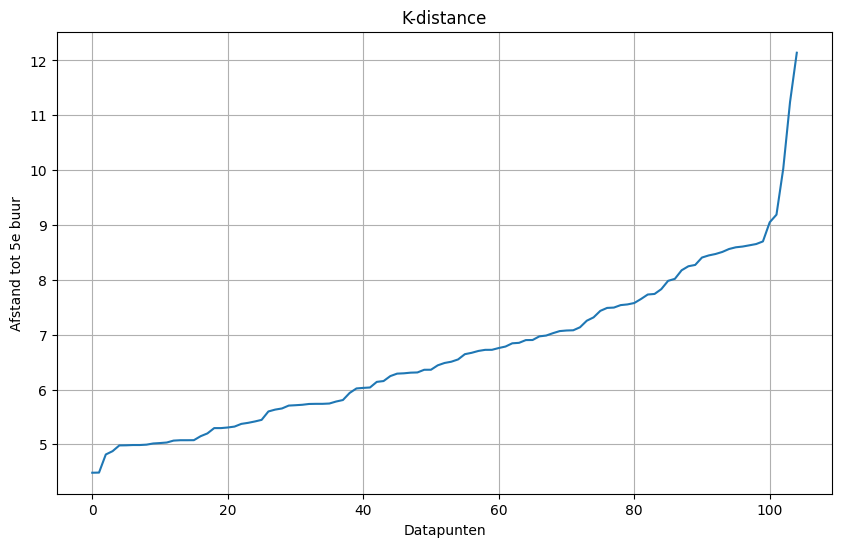

In [14]:
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-distance')
plt.xlabel('Datapunten')
plt.ylabel(f'Afstand tot {min_samples}e buur')
plt.grid(True)
plt.show()

In [15]:
#Ik DENK dat de elleboog op 9 zit
chosen_eps = 9

dbscan = DBSCAN(eps=chosen_eps, min_samples=min_samples)
clusters_dbscan = dbscan.fit_predict(X_scaled)


unlabeled_features['cluster_dbscan'] = clusters_dbscan

print("Aantal punten per cluster ( -1 = outlier ):")
print(unlabeled_features['cluster_dbscan'].value_counts())

Aantal punten per cluster ( -1 = outlier ):
cluster_dbscan
 0    102
-1      3
Name: count, dtype: int64


## Hoe werkt DBSCAN?

DBSCAN is een clustering algoritme dat clusters vormt op basis van dichtheid. In tegenstelling tot K-Means hoef je niet vooraf het aantal clusters ($K$) op te geven. Het algoritme classificeert punten in drie categorieën:
1. Core Points: Punten met minstens min_samples buren binnen een straal van `eps`.
2. Border Points: Punten die binnen de straal van een Core Point liggen, maar zelf niet genoeg buren hebben.
3. Noise: Punten die noch Core, noch Border zijn (uitbijters).

Parameters:
- $\epsilon$ (eps): De maximale afstand tussen twee punten om als buren te gelden.
- min_samples: Het minimum aantal punten (inclusief zichzelf) in de buurt om een "Core Point" te vormen.

Voorbeeld:
Stel we hebben een 2D dataset met 6 punten en we kiezen $\epsilon = 3$ en min_samples = 2.
Dataset:

$P1: (1, 2)$

$P2: (2, 2)$

$P3: (2, 3)$

$P4: (8, 7)$

$P5: (8, 8)$

$P6: (25, 80)$


We kijken naar de buren van $P1$ binnen straal 3.
- Afstand $P1 \leftrightarrow P2 = \sqrt{(2-1)^2 + (2-2)^2} = 1$ (Binnen straal)
- Afstand $P1 \leftrightarrow P3 = \sqrt{(2-1)^2 + (3-2)^2} = \sqrt{2} \approx 1.41$ (Binnen straal)
- Afstand $P1 \leftrightarrow P4 \approx 8.6$ (Buiten straal)

- P1: Heeft buren {P1, P2, P3}. Aantal = 3. Dit is $\ge 2$, dus Core Point. Cluster A start hier.
- P2: Heeft buren {P1, P2, P3}. Aantal = 3. Core Point. Zit in Cluster A.
- P3: Heeft buren {P1, P2, P3}. Aantal = 3. Core Point. Zit in Cluster A.
- P4: Heeft buren {P4, P5} (afstand is 1). Aantal = 2. Core Point. Nieuw Cluster B.
- P5: Heeft buren {P4, P5}. Aantal = 2. Core Point. Zit in Cluster B.
- P6: Heeft geen buren binnen straal 3 (dichtstbijzijnde is P5 op afstand ~74). Aantal = 1. Dit is $< 2$, dus Noise.

Cluster 1: P1, P2, P3

Cluster 2: P4, P5

Outlier (-1): P6

**bron**: https://www.datacamp.com/tutorial/dbscan-clustering-algorithm

## Waarom geen DBSCAN?
We gebruiken geen DBSCAN omdat DBSCAN is aangeraden bij het volgende:
- **Cluster shapes zijn complesx:** Bij ons is dat niet het geval, we hebben drie simpele clustergroepen.
- **We weten het aantal clusters niet:** Bij ons weten we dat wél, we hebben er maar drie.
- **Datasets hebben noise:** Dit zou in praktijk van deze opdracht wel kunnnen als we meer categoriën hadden.

**bron**: https://www.datacamp.com/tutorial/dbscan-clustering-algorithm

---

# Dimensionality Reduction (K-Means)

## PCA
PCA is een lineaire techniek voor dimensiereductie die probeert de meeste informatie (`variantie`) in de data te behouden. Het doet dit door nieuwe, niet-gecorrelreerde variabelen te vinden: de hoofdcomponenten (`Principal Components`).

1. Centreren: De data wordt gecentreerd rondom nul (gemiddelde aftrekken).

2. Covariantie: De covariantiematrix wordt berekend om te zien hoe variabelen samen variëren.

3. Eigenwaarden & Eigenvectoren: We berekenen de eigenvectoren (de richtingen van de grootste spreiding) en eigenwaarden (de grootte van die spreiding) van de covariantiematrix.

4. Projectie: De data wordt geprojecteerd op de eigenvectoren met de grootste eigenwaarden.

**Voorbeeld**

$X = \{(1, 2), (2, 3), (3, 4)\}$. We willen dit reduceren naar 1 dimensie.

Gemiddelde $\bar{x} = 2$, $\bar{y} = 3$.
Gecentreerde data $X_{cent}$: $\{(-1, -1), (0, 0), (1, 1)\}$. (Gemiddelde - Value)


Omdat $x$ en $y$ perfect gecorreleerd zijn (ze liggen op een lijn), is de richting van de grootste variantie diagonaal ($y=x$).


De vector die de lijn $y=x$ beschrijft is $v = [0.707, 0.707]$ (genormaliseerd). Dit is de eerste hoofdcomponent (`PC1`).

- Punt 1 $(-1, -1)$: $-1 \times 0.707 + -1 \times 0.707 = -1.41$
- Punt 2 $(0, 0)$: $0$
- Punt 3 $(1, 1)$: $1.41$

We zijn van 2 variabelen $(x, y)$ naar 1 variabele (PC1) gegaan.

---

Bij PCA kijken we naar de Explained Variance Ratio. Dit getal vertelt hoeveel procent van de originele informatie behouden blijft per component.

Methode: We maken een "cumulative explained variance" plot.

Keuze: We kiezen het aantal componenten waarbij de curve afvlakt of een bepaalde drempelwaarde overschrijdt (bijvoorbeeld 95% variantie). In de code hebben we gekozen voor n_components=0.95, wat betekent dat PCA net zoveel componenten kiest als nodig zijn om 95% van de variantie te verklaren.

**bron** https://towardsdatascience.com/principal-component-analysis-made-easy-a-step-by-step-tutorial-184f295e97fe/

## NMF
NMF is een techniek die een matrix $V$ (onze data) splitst in twee kleinere matrices $W$ en $H$, zodat $V \approx W \times H$.
Alle waarden in $W$ en $H$ moeten niet-negatief ($\ge 0$) zijn. Dit zorgt voor een opsommende opbouw: je kunt data alleen samenstellen door onderdelen op te tellen, niet door af te trekken. Dit maakt de features vaak beter interpreteerbaar (bijv. "hoeveelheid gitaar" + "hoeveelheid drums").

**Voorbeeld** 
We hebben $V$ die de aanwezigheid van instrumenten (Rijen) in liedjes (Kolommen) voorstelt.
$V = \begin{bmatrix} 4 & 0 \\ 2 & 1 \\ 0 & 5 \end{bmatrix}$ (3 features, 2 liedjes)
We willen dit reduceren naar 2 basis-patronen (dimensies). NMF zoekt $W$ en $H$ zodat $W \times H \approx V$.
Stel NMF vindt:
$W = \begin{bmatrix} 2 & 0 \\ 1 & 0.2 \\ 0 & 2.5 \end{bmatrix}$ (Basispatronen: Kolom 1 is 'Genre A', Kolom 2 is 'Genre B')
$H = \begin{bmatrix} 2 & 0 \\ 0 & 2 \end{bmatrix}$ (Coëfficiënten: Liedje 1 bestaat uit $2 \times$ patroon 1, Liedje 2 uit $2 \times$ patroon 2)
Controle $W \times H$:

Linksboven: $(2\times2) + (0\times0) = 4$ 

Rechtsonder: $(0\times0) + (2.5\times2) = 5$ 

---

Bij NMF is er geen directe "explained variance" zoals bij PCA.Methode: We kunnen kijken naar de Reconstruction Error (hoe groot is het verschil tussen $V$ en $W \times H$) bij verschillende aantallen componenten. De "elleboog" in deze grafiek is vaak optimaal.Onze keuze: Omdat we weten dat we zoeken naar 3 muziekgenres, is het logisch om het aantal componenten (latente features) gelijk te stellen aan 3. We dwingen het algoritme om de data uit te drukken als een mix van 3 basis-genres.

**bron** https://www.audiolabs-erlangen.de/resources/MIR/FMP/C8/C8S3_NMFbasic.html

## Verschillen en overeenkomsten PCA en NMF

**Verschillen:**
- NMF moet positieve data zijn terwijl PCA het niet uitmaakt.
- PCA is orthogonaal (dus +- getallen) terwijl NMF features worden opgebouwd door te tellen en delen.


**Overeenkomsten:**
- Beiden worden gebruikt voor dimensionality reduction.
- Worden gebruikt voor feature extraction.

In [16]:
from sklearn.decomposition import PCA, NMF
from sklearn.preprocessing import MinMaxScaler

#PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA heeft het aantal features teruggebracht van {X_scaled.shape[1]} naar {X_pca.shape[1]}")

kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
unlabeled_features['cluster_pca'] = kmeans_pca.fit_predict(X_pca)



#NMF
#Hier worden de features opgehaald
X_raw = unlabeled_features.drop(['filename', 'cluster_dbscan', 'cluster_pca', 'clusters', 'genre'], axis=1, errors='ignore')

#MinMax om 0-1 (positief)
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_raw)

nmf = NMF(n_components=3, init='random', random_state=42)
X_nmf = nmf.fit_transform(X_mm)

kmeans_nmf = KMeans(n_clusters=3, random_state=42, n_init=10)
unlabeled_features['cluster_nmf'] = kmeans_nmf.fit_predict(X_nmf)

print("PCA en NMF clustering toegevoegd aan 'unlabeled_features'.")

PCA heeft het aantal features teruggebracht van 68 naar 25
PCA en NMF clustering toegevoegd aan 'unlabeled_features'.


We testen hier de algoritmes op de standaard methodes van alle drie soorten K-Means clustering

In [17]:
original_labels = unlabeled_features['clusters'] 

score_orig = silhouette_score(X_scaled, original_labels)
score_pca = silhouette_score(X_pca, unlabeled_features['cluster_pca'])
score_nmf = silhouette_score(X_nmf, unlabeled_features['cluster_nmf'])

print("Scores vergelijken")
print(f"Originele data (alle features): {score_orig:.4f}")
print(f"PCA (gereduceerde features):    {score_pca:.4f}")
print(f"NMF (gereduceerde features):    {score_nmf:.4f}")

print("\nConclusie:")
best_score = max(score_orig, score_pca, score_nmf)
if best_score == score_orig:
    print("De originele dataset geeft de best gescheiden clusters.")
elif best_score == score_pca:
    print("PCA heeft geleid tot betere/duidelijkere clusters.")
else:
    print("NMF heeft geleid tot betere/duidelijkere clusters.")

Scores vergelijken
Originele data (alle features): 0.3083
PCA (gereduceerde features):    0.3298
NMF (gereduceerde features):    0.7075

Conclusie:
NMF heeft geleid tot betere/duidelijkere clusters.


# De App

In [18]:
class MusicRecommender:
    def __init__(self, feature_matrix, filenames):
        self.feature_matrix = feature_matrix
        self.filenames = filenames.reset_index(drop=True)
        self.model = NearestNeighbors(n_neighbors=6, metric='cosine')
        self.model.fit(self.feature_matrix)
    
    def recommend(self, filename):
        matches = self.filenames[self.filenames == filename]
            
        idx = matches.index[0]
        
        query = self.feature_matrix[idx].reshape(1, -1)

        distances, indices = self.model.kneighbors(query)
        
        recommendations = []
        for i in range(1, len(indices[0])):
            rec_idx = indices[0][i]
            rec_dist = distances[0][i]
            rec_name = self.filenames.iloc[rec_idx]
            recommendations.append((rec_name, rec_dist))
            
        return recommendations

app = MusicRecommender(X_scaled, unlabeled_features['filename'])


test_file = unlabeled_features['filename'].iloc[0]

print(f"Speel nu: {test_file} ---")
recs = app.recommend(test_file)

for name, dist in recs:
    print(f"Nummer: {name:<30} (Afstand: {dist:.4f})")

Speel nu: m00003.wav ---
Nummer: m00043.wav                     (Afstand: 0.2318)
Nummer: m00927.wav                     (Afstand: 0.2322)
Nummer: m00391.wav                     (Afstand: 0.2390)
Nummer: m00852.wav                     (Afstand: 0.2499)
Nummer: m00289.wav                     (Afstand: 0.2522)


## Opdracht 3 Bevindingen en conclusie

*Belangrijkste features voor clustering:*

- **MFCC’s (mfcc_1 t/m mfcc_13 en hun standaarddeviaties)**  
  Deze features beschrijven de klankkleur van audio en bleken zeer belangrijk om genres te onderscheiden, omdat zij een groot deel van de variatie in de dataset verklaren. Dit blijkt uit:  
  - na standaardisatie dragen MFCC’s relatief sterk bij aan de afstandsberekening in KMeans  
  - bestanden met vergelijkbare MFCC profielen kwamen consequent in dezelfde clusters terecht  
  - de clusters die uiteindelijk als classical, pop en metal zijn geïnterpreteerd, vertoonden duidelijke verschillen in klankkleur, direct vastgelegd door MFCC’s  

- **Spectrale features (spectral centroid, spectral bandwidth, rolloff)**  
  Spectrale features zijn belangrijk bij het onderscheiden van muziek met verschillende frequentiekarakteristieken. Bewijzen hiervan zijn:  
  - duidelijke daling in inertia bij lage waarden van k in de Elbow-methode, wat aangeeft dat verschillen in frequentieverdeling snel leiden tot compacte clusters  
  - genres met veel hoge frequenties (zoals metal) kwamen consistent in een apart cluster terecht  
  - de scheiding bleef behouden bij verschillende aantallen clusters en verschillende algoritmen  

- **Ritmische features (tempo, onset_strength, tempogram)**  
  Vooral relevant om pop en metal te onderscheiden van klassieke muziek, die vaak minder sterke en regelmatige beats heeft. Dit blijkt uit:  
  - hogere silhouette score bij k = 3 (0,30) bij hierarchische clustering, wat wijst op goed gescheiden clusters op basis van ritmische structuur  
  - nummers met duidelijke beats en hogere onset strength werden vaker samen geclusterd  
  - classical-muziek is minder sterk vertegenwoordigd in clusters met hoge ritmische consistentie


**Effect en nut van dimensionality reduction (PCA en NMF)**

In dit onderzoek zijn zowel PCA als NMF toegepast. Het doel was om ruis en redundantie te verminderen, terwijl de belangrijkste verschillen tussen nummers behouden blijven.

**Resultaten uit ons onderzoek:**

- **PCA**  
  - Toepassing: `n_components=0.95`, waardoor 95% van de variantie behouden blijft  
  - Reductie van features: van `X_scaled.shape[1]` naar `X_pca.shape[1]`  
  - Clustering met KMeans op de gereduceerde data gaf een **silhouette score van 0,3298**, iets beter dan de originele dataset (0,3083)  
  - Conclusie: PCA behoudt de globale structuur, maakt clusters iets duidelijker en reduceert de dataset tot een compacter formaat

- **NMF**  
  - Toepassing op de gestandaardiseerde en geschaalde data  
  - Resultaat: clusters waren aanzienlijk beter gescheiden, met een **silhouette score van 0,7075**  
  - Conclusie: NMF vangt latentere patronen in de audiofeatures en versterkt het onderscheid tussen de drie genres

**Algemene conclusie:**  
Dimensionality reduction helpt om de dataset overzichtelijker en minder ruisgevoelig te maken, terwijl de clusteringkwaliteit verbetert. PCA behoudt de globale structuur en vergemakkelijkt visualisatie, maar **NMF levert de duidelijkste clusters** voor dit onderzoek.


Om betere aanbevelingen te doen zouden we extra gegevens willen hebben. Bijvoorbeeld meer en langere audiofragmenten per nummer, zodat de features representatiever zijn. Tijdelijke veranderingen in klank en ritme kunnen helpen grensgevallen beter te onderscheiden. Daarnaast zouden metadata (zoals artiest, subgenre of jaartal) en gebruikersgedrag (likes, skips) het mogelijk maken om clusters te koppelen aan context en voorkeuren, waardoor aanbevelingen relevanter worden.